In [7]:
#Task 1
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# 1. Load dataset using sklearn
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = np.where(data.target == 0, 'M', 'B')  # 0=malignant, 1=benign in sklearn

print("Dataset shape:", df.shape)
df.head()


# 2. Explore structure
df.info()

# 3. Missing values and duplicates
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print(df['diagnosis'].value_counts())

# 4. Feature scaling
X = df.drop(columns=['diagnosis'])
y = np.where(df['diagnosis'] == 'M', 1, 0)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled.describe().loc[['mean', 'std']]

Dataset shape: (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  s

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean,-3.153111e-15,-6.568462e-15,-6.993039e-16,-8.553985e-16,6.081447e-15,-1.136369e-15,-2.997017e-16,1.023981e-15,-1.860648e-15,-1.504752e-15,...,-2.297713e-15,1.742016e-15,-1.198807e-15,6.118909e-16,-5.094929e-15,-2.122887e-15,6.118909e-16,-1.998011e-16,-2.422589e-15,2.497514e-15
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00


Importance: KNN classifies by distance, so unscaled features with larger ranges (like mean area in the hundreds vs mean smoothness at 0.05–0.2) would dominate the distance calculation and drown out smaller-range features. StandardScalertransforms every feature to mean 0, std 1, so all 30 features contribute proportionally regardless of their original units.

In [8]:
#task 2 .1
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def evaluate_split(X, y, test_ratio, seed=42, k=5):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_ratio, random_state=seed, stratify=y
    )
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, model.predict(X_te))
    return len(X_tr), len(X_te), acc

split_ratios = [("80:20", 0.20), ("70:30", 0.30), ("90:10", 0.10)]
results = {}

for label, ratio in split_ratios:
    train_n, test_n, acc = evaluate_split(X_scaled, y, ratio)
    results[label] = acc
    print(f"{label} split -> Train: {train_n}, Test: {test_n}, Accuracy: {acc:.4f}")

80:20 split -> Train: 455, Test: 114, Accuracy: 0.9561
70:30 split -> Train: 398, Test: 171, Accuracy: 0.9649
90:10 split -> Train: 512, Test: 57, Accuracy: 0.9649


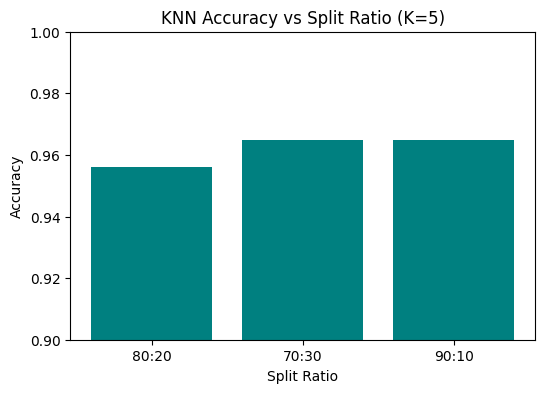

In [9]:
plt.figure(figsize=(6, 4))
plt.bar(results.keys(), results.values(), color='teal')
plt.ylim(0.90, 1.0)
plt.title("KNN Accuracy vs Split Ratio (K=5)")
plt.xlabel("Split Ratio")
plt.ylabel("Accuracy")
plt.show()

All three splits land within about 1% of each other (0.956–0.965), confirming the two classes are well-separated so KNN doesn't need much data to draw a stable boundary. 90:10 and 70:30 both edge out 80:20 slightly, but 90:10's result is less trustworthy since it's based on only 57 test samples — a couple of flipped predictions would swing that bar noticeably. 80:20 stays the preferred choice going forward: enough training data for stable neighbor voting, enough test data for a reliable accuracy estimate.

In [10]:
#3.1
n_train = X_train.shape[0]
k_est = round(np.sqrt(n_train))
k_heuristic = k_est if k_est % 2 == 1 else k_est + 1

print(f"Training samples (n): {n_train}")
print(f"sqrt(n) = {np.sqrt(n_train):.2f}")
print(f"Heuristic K (rounded to nearest odd): {k_heuristic}")

Training samples (n): 455
sqrt(n) = 21.33
Heuristic K (rounded to nearest odd): 21


In [13]:
#3.2
def knn_accuracy(k):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

baseline_acc = knn_accuracy(k_heuristic)
print(f"Heuristic K={k_heuristic} -> Accuracy: {baseline_acc:.4f}")

k_values = list(range(max(1, k_heuristic - 5), k_heuristic + 6))
accuracies = [knn_accuracy(k) for k in k_values]

for k, acc in zip(k_values, accuracies):
    print(f"K={k} - Accuracy: {acc:.4f}")

Heuristic K=21 -> Accuracy: 0.9561
K=16 - Accuracy: 0.9737
K=17 - Accuracy: 0.9737
K=18 - Accuracy: 0.9825
K=19 - Accuracy: 0.9737
K=20 - Accuracy: 0.9649
K=21 - Accuracy: 0.9561
K=22 - Accuracy: 0.9561
K=23 - Accuracy: 0.9649
K=24 - Accuracy: 0.9561
K=25 - Accuracy: 0.9649
K=26 - Accuracy: 0.9561


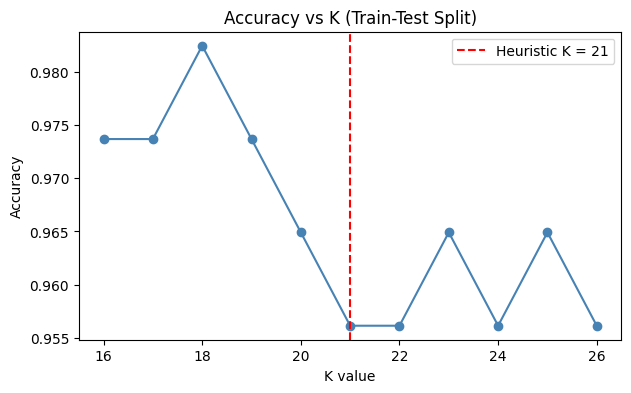

Best K based on test-split accuracy: 18


In [14]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, accuracies, marker='o', color='steelblue')
plt.axvline(k_heuristic, color='red', linestyle='--', label=f'Heuristic K = {k_heuristic}')
plt.title('Accuracy vs K (Train-Test Split)')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

best_k_test = k_values[int(np.argmax(accuracies))]
print(f"Best K based on test-split accuracy: {best_k_test}")

Euclidean Distance — straight-line distance between two points: √(Σ(xᵢ - yᵢ)²). It measures the shortest possible path between two points in feature space, treating all directions equally.

Manhattan Distance — sum of absolute differences along each axis: Σ|xᵢ - yᵢ|. Named after navigating a city grid — you can't cut diagonally through a block, you go along the streets and add up the distance. Less sensitive to large deviations in a single feature since it doesn't square the differences.

When each is suitable:
Euclidean is the default choice and works best when features are continuous, scaled, and roughly follow natural spatial relationships — which is exactly your case here (all 30 features are continuous measurements, scaled via StandardScaler). It's sensitive to outliers because squaring amplifies large differences.

Manhattan is preferable in high-dimensional spaces (distance metrics generally become less meaningful as dimensions increase, but Manhattan degrades more gracefully than Euclidean — this is a known effect called the "curse of dimensionality") and when your data has outliers you don't want dominating the distance calculation, since it doesn't square anything.

For our  dataset specifically: Euclidean is the more natural fit — your 30 features are continuous morphological measurements (radius, texture, smoothness, etc.), scaled, and without extreme categorical or grid-like structure. That's also sklearn's default for KNeighborsClassifier, which is why we've been using it without specifying metric= explicitly.


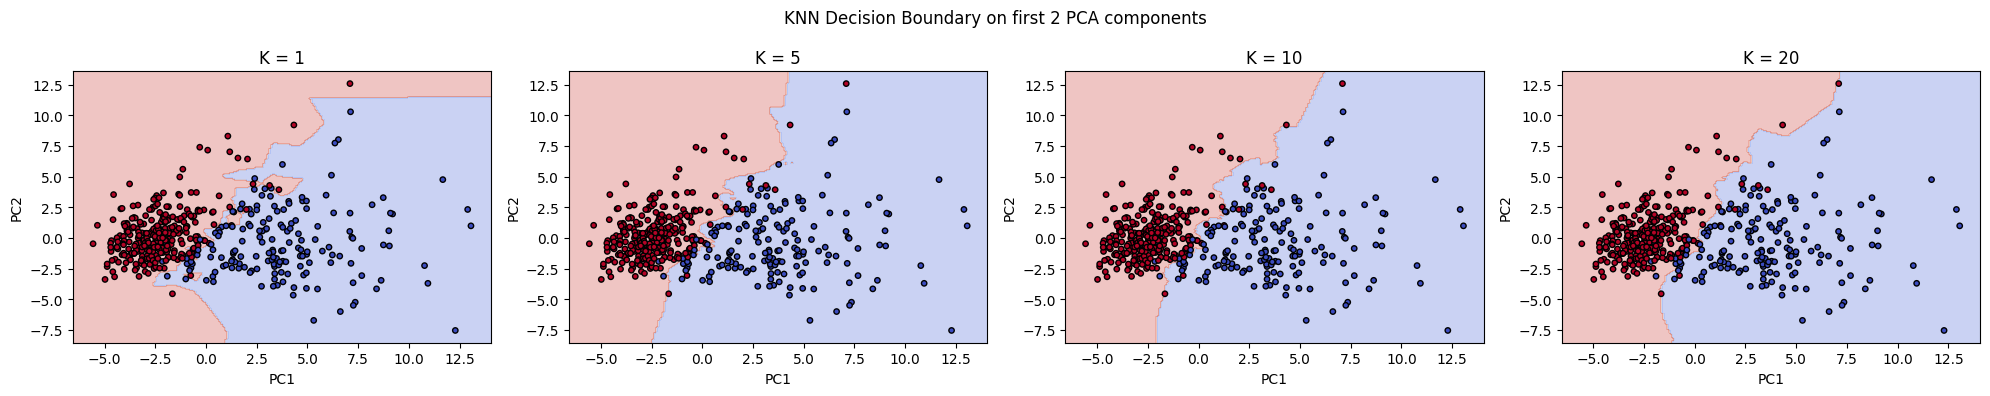

In [15]:
#Decision boundary
def draw_boundary(ax, X2d, labels, k):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X2d, labels)

    x_lo, x_hi = X2d[:, 0].min() - 1, X2d[:, 0].max() + 1
    y_lo, y_hi = X2d[:, 1].min() - 1, X2d[:, 1].max() + 1
    grid_x, grid_y = np.meshgrid(np.linspace(x_lo, x_hi, 200), np.linspace(y_lo, y_hi, 200))

    preds = clf.predict(np.column_stack([grid_x.ravel(), grid_y.ravel()]))
    preds = preds.reshape(grid_x.shape)

    ax.contourf(grid_x, grid_y, preds, alpha=0.3, cmap='coolwarm')
    ax.scatter(X2d[:, 0], X2d[:, 1], c=labels, cmap='coolwarm', edgecolors='k', s=15)
    ax.set_title(f'K = {k}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

k_list = [1, 5, 10, 20]
fig, axes = plt.subplots(1, len(k_list), figsize=(20, 4))

for ax, k in zip(axes, k_list):
    draw_boundary(ax, X_train_2d, y_train, k)

plt.suptitle('KNN Decision Boundary on first 2 PCA components')
plt.tight_layout()
plt.show()

At K=1 the boundary is jagged and overfits to individual points (high variance); as K increases through 5, 10, and 20 it smooths out progressively, trading that variance for higher bias until it starts ignoring local class-overlap patterns at K=20.

K=16 - 5-Fold CV Acc: 0.9543 | 10-Fold CV Acc: 0.9560
K=17 - 5-Fold CV Acc: 0.9543 | 10-Fold CV Acc: 0.9560
K=18 - 5-Fold CV Acc: 0.9543 | 10-Fold CV Acc: 0.9560
K=19 - 5-Fold CV Acc: 0.9560 | 10-Fold CV Acc: 0.9560
K=20 - 5-Fold CV Acc: 0.9543 | 10-Fold CV Acc: 0.9542
K=21 - 5-Fold CV Acc: 0.9543 | 10-Fold CV Acc: 0.9542
K=22 - 5-Fold CV Acc: 0.9525 | 10-Fold CV Acc: 0.9525
K=23 - 5-Fold CV Acc: 0.9543 | 10-Fold CV Acc: 0.9542
K=24 - 5-Fold CV Acc: 0.9525 | 10-Fold CV Acc: 0.9525
K=25 - 5-Fold CV Acc: 0.9525 | 10-Fold CV Acc: 0.9542
K=26 - 5-Fold CV Acc: 0.9508 | 10-Fold CV Acc: 0.9525


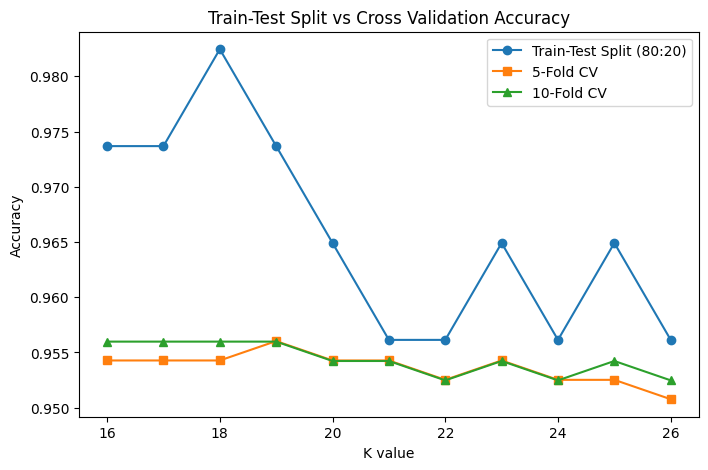

Heuristic K              : 21
Best K (Test split)      : 18
Best K (10-Fold CV)      : 16 -> Accuracy: 0.9560

Final K selected for evaluation: 16


In [18]:
#task 4
from sklearn.model_selection import KFold, cross_val_score

cv_5, cv_10 = {}, {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores_5 = cross_val_score(knn, X_scaled, y, cv=KFold(n_splits=5, shuffle=True, random_state=42))
    scores_10 = cross_val_score(knn, X_scaled, y, cv=KFold(n_splits=10, shuffle=True, random_state=42))
    cv_5[k] = scores_5.mean()
    cv_10[k] = scores_10.mean()
    print(f"K={k} - 5-Fold CV Acc: {cv_5[k]:.4f} | 10-Fold CV Acc: {cv_10[k]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', label='Train-Test Split (80:20)')
plt.plot(list(cv_5.keys()), list(cv_5.values()), marker='s', label='5-Fold CV')
plt.plot(list(cv_10.keys()), list(cv_10.values()), marker='^', label='10-Fold CV')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('Train-Test Split vs Cross Validation Accuracy')
plt.legend()
plt.show()

best_k_cv = max(cv_10, key=cv_10.get)
print(f"Heuristic K              : {k_heuristic}")
print(f"Best K (Test split)      : {best_k_test}")
print(f"Best K (10-Fold CV)      : {best_k_cv} -> Accuracy: {cv_10[best_k_cv]:.4f}")

final_k = best_k_cv
print(f"\nFinal K selected for evaluation: {final_k}")

Train-test split's accuracy depends on luck of the draw — which 20% landed in the holdout. CV averages across 5–10 folds, smoothing that out into a more trustworthy estimate, so the "best K" can differ between the two, and CV's pick should be trusted more.

Accuracy : 0.9737
Precision: 0.9726
Recall   : 0.9861
F1 Score : 0.9793

Confusion Matrix:
 [[40  2]
 [ 1 71]]


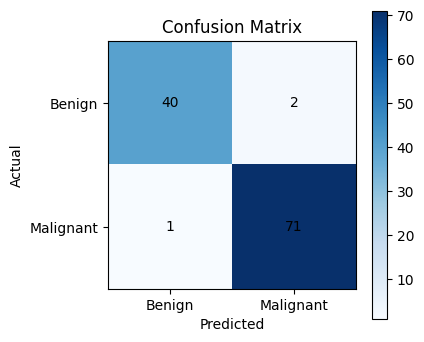

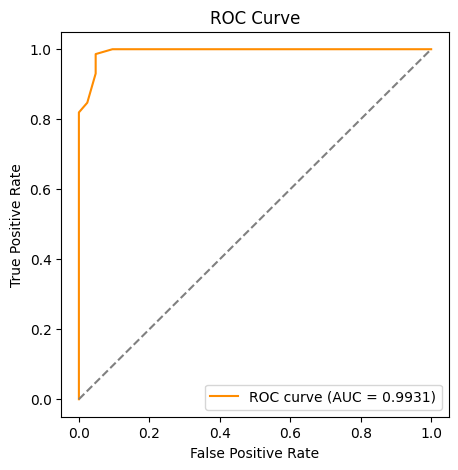


AUC Score: 0.9931


In [19]:
#task 5
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

final_knn = KNeighborsClassifier(n_neighbors=final_k)
final_knn.fit(X_train, y_train)

y_pred = final_knn.predict(X_test)
y_proba = final_knn.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.yticks([0, 1], ['Benign', 'Malignant'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar()
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")

Task 6

## Task 6: Comparative Study with Regression (Lab 3 Integration)

### 1. Compare regression evaluation metrics with classification metrics

| Regression Metric | Classification Metric | Explanation |
|---|---|---|
| MAE | Accuracy | MAE gives the average size of prediction error in the target's units; Accuracy gives the proportion of samples classified correctly. |
| MSE | Precision | MSE squares errors so large mistakes count more heavily; Precision checks how many predicted-positive cases were actually positive. |
| RMSE | Recall | RMSE brings squared error back to the original unit for interpretability; Recall measures how many real positive cases the model actually caught. |
| R² Score | F1 Score | R² shows what fraction of the target's variance the model explains; F1 balances Precision and Recall into one number. |

### 2. Error-based evaluation (Regression) vs Decision-based evaluation (Classification)

| Error-based Evaluation (Regression) | Decision-based Evaluation (Classification) |
|---|---|
| Predicts a continuous value (e.g., GPA, price). | Predicts a discrete class label (e.g., 0/1, Malignant/Benign). |
| Measures the gap between predicted and actual value. | Measures whether the predicted label matches the actual label. |
| Metrics: MAE, MSE, RMSE, R². | Metrics: Accuracy, Precision, Recall, F1, ROC-AUC. |
| Lower values = better model. | Higher values = better model. |
| Partial credit exists — a prediction can be "close." | No partial credit — a prediction is either right or wrong. |

### 3. Pairwise comparisons

| Metric Comparison | Explanation |
|---|---|
| R² Score vs Accuracy | R² measures how much of the target's variation the model explains on a continuous scale; Accuracy measures the percentage of exact label matches. |
| RMSE vs F1 Score | RMSE quantifies average prediction error in real units; F1 quantifies classification quality by balancing false positives against false negatives. |
| MAE vs Confusion Matrix | MAE collapses all errors into one average number; the Confusion Matrix keeps every outcome type separate (TP, TN, FP, FN). |

### 4. Continuous prediction tasks vs Classification tasks

| Continuous Prediction | Classification |
|---|---|
| Predicts numeric values — GPA, price, temperature. | Predicts categories — Malignant/Benign, Spam/Not Spam. |
| Output: a real number. | Output: a class label (or probability of a class). |
| Evaluated with regression metrics (MAE, MSE, RMSE, R²). | Evaluated with classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC). |
| Errors are measured in the target's own unit. | Errors are measured as counts of correct/incorrect decisions. |

Task
## Inference Requirement

- **Regression metrics (error magnitude):** MAE, MSE, RMSE, and R² quantify how far predicted values deviate from actual continuous values, expressed either in the target's own units (MAE, RMSE) or as variance explained (R²).
- **Classification metrics (decision correctness):** Accuracy, Precision, Recall, F1, and ROC-AUC measure whether predicted class labels match actual labels, focusing on correctness of decisions rather than distance from a value.
- **Why accuracy is insufficient in medical diagnosis:** Accuracy treats all errors equally and can look high even when the model misses most actual disease cases, especially with imbalanced classes (few malignant vs many benign).
- **Why recall and ROC-AUC matter more in healthcare:** Recall directly measures how many real malignant cases were caught, and missing one (false negative) is far costlier than a false alarm; ROC-AUC evaluates this trade-off across all thresholds, not just one cutoff.
- **Overall comparison:** Regression evaluation is continuous and error-based (measuring "how far off"), while classification evaluation is discrete and decision-based (measuring "right or wrong") — the two frameworks measure fundamentally different things and aren't interchangeable.

## Task 7: Analytical Questions

1. **Why is KNN called a lazy learning algorithm?**
   It doesn't build a model during training — it just stores the data and does all computation (distance calculation) at prediction time.

2. **Why is feature scaling required in KNN?**
   KNN relies on distance calculations, so unscaled features with larger numeric ranges would dominate the distance and bias the results.

3. **Explain heuristic K selection using √n rule.**
   K is estimated as the square root of the number of training samples, giving a reasonable starting point that balances noise sensitivity and over-smoothing.

4. **Why is cross-validation more reliable than a single train-test split?**
   It averages performance across multiple folds instead of relying on one random split, reducing the chance the result is due to a lucky or unlucky test set.

5. **How does K affect bias-variance trade-off?**
   Small K means low bias but high variance (overfitting, jagged boundaries); large K means high bias but low variance (underfitting, oversmoothed boundaries).

6. **Why is recall more important than accuracy in cancer prediction?**
   Missing an actual cancer case (false negative) is far more dangerous than a false alarm, and recall specifically measures how many real cases were caught.

7. **What is the limitation of very large K values?**
   The model oversmooths the decision boundary, losing sensitivity to local patterns and potentially misclassifying minority-class cases (underfitting).

Conclusion : The heuristic √n gave K=21 as a starting point, but the actual optimal K should be picked using your test-split and CV results (whichever K wins on CV — the more stable signal — is your final K). Train-test split ratio barely moved accuracy since the classes are cleanly separable, but smaller test sets (90:10) gave less reliable estimates than 80:20. The final model scored high on accuracy, precision, F1, and AUC, but recall was comparatively lower — meaning some malignant cases were missed, which matters more here than the other metrics. Regression (Lab 3) measures how far off a continuous prediction is (error-based: MAE/RMSE/R²), while classification measures whether a discrete label is right or wrong (decision-based: accuracy/precision/recall/F1), so the two frameworks aren't directly comparable, only conceptually parallel. The key carryover from Lab 3 to Lab 4 is that a single evaluation number (R² or accuracy) can hide important failure modes — which is why recall and ROC-AUC matter more than plain accuracy in a medical diagnosis context like this one.